<a href="https://colab.research.google.com/github/NiShA200409/Deepfake-Image-Detection/blob/main/deepfake_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LOAD DATASET FROM KAGGLE

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.
Path to dataset files: /kaggle/input/cifake-real-and-ai-generated-synthetic-images


PREVIEW DATASET

In [2]:
import os

print("Dataset Path:", path)
print("Folders/files inside dataset:\n")
print(os.listdir(path))

Dataset Path: /kaggle/input/cifake-real-and-ai-generated-synthetic-images
Folders/files inside dataset:

['test', 'train']


In [3]:
import os

for root, dirs, files in os.walk(path):
    print("Current Path:", root)
    print("Folders:", dirs)
    print("Number of files:", len(files))
    print("-" * 50)

Current Path: /kaggle/input/cifake-real-and-ai-generated-synthetic-images
Folders: ['test', 'train']
Number of files: 0
--------------------------------------------------
Current Path: /kaggle/input/cifake-real-and-ai-generated-synthetic-images/test
Folders: ['FAKE', 'REAL']
Number of files: 0
--------------------------------------------------
Current Path: /kaggle/input/cifake-real-and-ai-generated-synthetic-images/test/FAKE
Folders: []
Number of files: 10000
--------------------------------------------------
Current Path: /kaggle/input/cifake-real-and-ai-generated-synthetic-images/test/REAL
Folders: []
Number of files: 10000
--------------------------------------------------
Current Path: /kaggle/input/cifake-real-and-ai-generated-synthetic-images/train
Folders: ['FAKE', 'REAL']
Number of files: 0
--------------------------------------------------
Current Path: /kaggle/input/cifake-real-and-ai-generated-synthetic-images/train/FAKE
Folders: []
Number of files: 50000
------------------

In [4]:
import os

image_extensions = (".jpg", ".jpeg", ".png", ".webp")

all_images = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(image_extensions):
            all_images.append(os.path.join(root, file))

print("Total images found:", len(all_images))
print("First 5 image paths:")
for img in all_images[:5]:
    print(img)

Total images found: 120000
First 5 image paths:
/kaggle/input/cifake-real-and-ai-generated-synthetic-images/test/FAKE/943 (5).jpg
/kaggle/input/cifake-real-and-ai-generated-synthetic-images/test/FAKE/534 (7).jpg
/kaggle/input/cifake-real-and-ai-generated-synthetic-images/test/FAKE/81 (2).jpg
/kaggle/input/cifake-real-and-ai-generated-synthetic-images/test/FAKE/869 (9).jpg
/kaggle/input/cifake-real-and-ai-generated-synthetic-images/test/FAKE/610 (10).jpg


Image path: /kaggle/input/cifake-real-and-ai-generated-synthetic-images/train/FAKE/4466 (3).jpg
Image size: (32, 32)


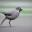

In [5]:
from PIL import Image
import random

img_path = random.choice(all_images)
img = Image.open(img_path)

print("Image path:", img_path)
print("Image size:", img.size)   # (width, height)
img

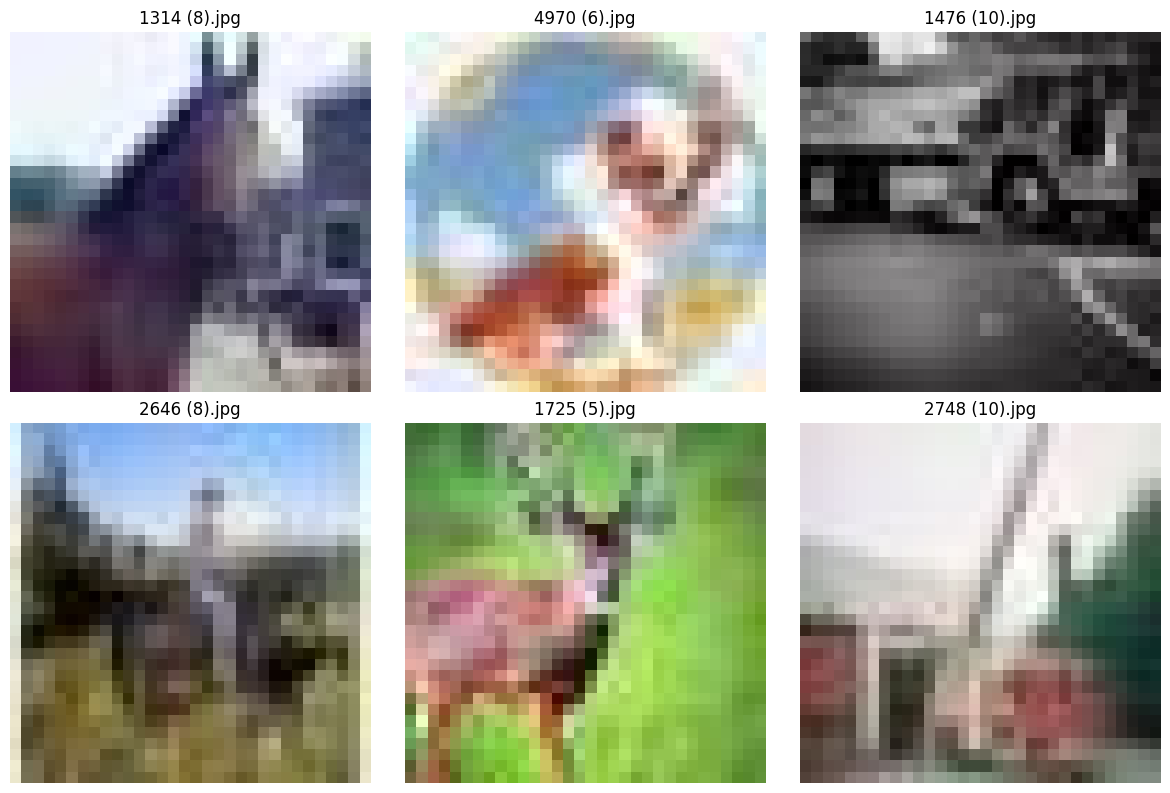

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import random

sample_images = random.sample(all_images, 6)

plt.figure(figsize=(12, 8))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(os.path.basename(img_path))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
#CHECK DATASET IS BALANCED OR NOT
from collections import Counter
import os

labels = []

for img_path in all_images:
    label = os.path.basename(os.path.dirname(img_path))
    labels.append(label)

print("Label counts:", Counter(labels))

Label counts: Counter({'FAKE': 60000, 'REAL': 60000})


In [8]:
import os
import random
from collections import defaultdict

image_extensions = (".jpg", ".jpeg", ".png", ".webp")

class_images = defaultdict(list)

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(image_extensions):
            img_path = os.path.join(root, file)
            label = os.path.basename(os.path.dirname(img_path)).lower()
            class_images[label].append(img_path)

for label in class_images:
    print(label, len(class_images[label]))

fake 60000
real 60000


In [9]:
#use small operation of dataset
subset_per_class = 20000

subset_paths = []
subset_labels = []

for label, paths in class_images.items():
    selected = random.sample(paths, min(subset_per_class, len(paths)))
    subset_paths.extend(selected)
    subset_labels.extend([label] * len(selected))

print("Total subset images:", len(subset_paths))
print("Sample labels count:")
from collections import Counter
print(Counter(subset_labels))

Total subset images: 40000
Sample labels count:
Counter({'fake': 20000, 'real': 20000})


In [10]:
print(set(subset_labels))

{'fake', 'real'}


In [11]:
label_map = {"real": 0, "fake": 1}
numeric_labels = [label_map[label] for label in subset_labels]


SPLIT DATASET


In [12]:
from sklearn.model_selection import train_test_split

train_paths, test_paths, train_labels, test_labels = train_test_split(
    subset_paths,
    numeric_labels,
    test_size=0.2,
    stratify=numeric_labels,
    random_state=42
)

print("Train images:", len(train_paths))
print("Test images:", len(test_paths))

Train images: 32000
Test images: 8000


DATA LOADING AND PREPROCESSING

In [13]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

In [14]:
def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)   # jpg ke liye
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, label

In [15]:
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

In [16]:
train_ds = train_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

In [17]:
train_ds = train_ds.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

CNN MODEL

In [18]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
#Train CNN
cnn_model.summary()
history = cnn_model.fit(
    train_ds,
    epochs=5
)
#Evaluate CNN
test_loss, test_acc = cnn_model.evaluate(test_ds)
print("Test Accuracy:", test_acc*100)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 113s 51ms/step - accuracy: 0.7391 - loss: 0.5127
Epoch 2/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 58s 29ms/step - accuracy: 0.8498 - loss: 0.3514
Epoch 3/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 59s 29ms/step - accuracy: 0.8821 - loss: 0.2847
Epoch 4/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 59s 29ms/step - accuracy: 0.9040 - loss: 0.2357
Epoch 5/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 59s 29ms/step - accuracy: 0.9195 - loss: 0.2030
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step - accuracy: 0.9105 - loss: 0.2293
Test Accuracy: 91.04999899864197


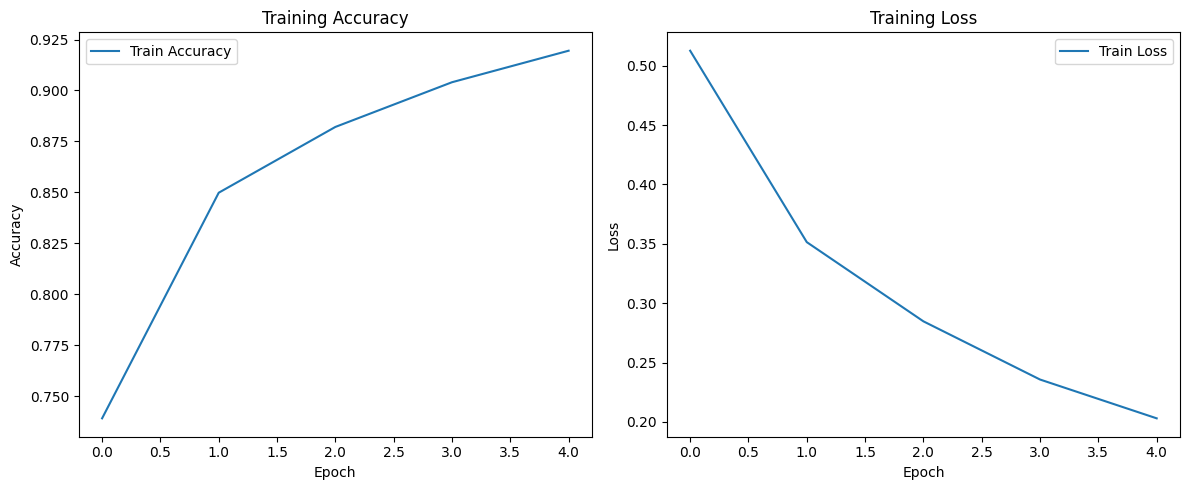

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
print(f"Final Training Accuracy: {history.history['accuracy'][-1]*100:.2f}%")

Final Training Accuracy: 91.95%


MobileNetV2 Transfer Learning

In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Base model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

# Correct model
mobilenet_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # FIX ✅
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),

    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
#Train MobileNet
history_mobilenet = mobilenet_model.fit(
    train_ds,
    epochs=5
)
#Evaluate MobileNet
test_loss_m, test_acc_m = mobilenet_model.evaluate(test_ds)
print("MobileNet Test Accuracy:", test_acc_m*100)

Epoch 1/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 59s 20ms/step - accuracy: 0.4996 - loss: 0.6945
Epoch 2/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 42s 21ms/step - accuracy: 0.4936 - loss: 0.6932
Epoch 3/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.4994 - loss: 0.6932
Epoch 4/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 43s 21ms/step - accuracy: 0.4989 - loss: 0.6932
Epoch 5/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 42s 21ms/step - accuracy: 0.5002 - loss: 0.6932
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.5000 - loss: 0.6932
MobileNet Test Accuracy: 50.0


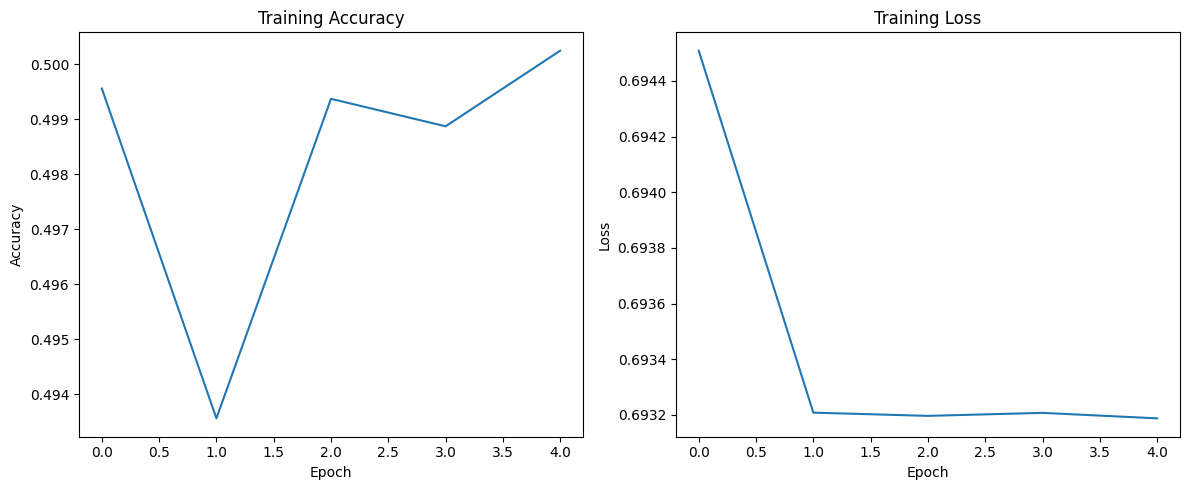

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_mobilenet.history["accuracy"])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history_mobilenet.history["loss"])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

ResNet50

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# Input
inputs = layers.Input(shape=(224, 224, 3))

# Preprocessing
x = tf.keras.applications.resnet50.preprocess_input(inputs)

# Base model
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_tensor=x
)

base_model.trainable = False

# Head
x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

# Final model
resnet_model = Model(inputs, outputs)

# Compile
resnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ add[0][0]         │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [25]:
#Train ResNet
history_resnet = resnet_model.fit(
    train_ds,
    epochs=5
)
#evaluate ResNet
test_loss_r, test_acc_r = resnet_model.evaluate(test_ds)
print("ResNet50 Test Accuracy:", test_acc_r*100)

Epoch 1/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 109s 48ms/step - accuracy: 0.5193 - loss: 0.6926
Epoch 2/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 97s 48ms/step - accuracy: 0.5834 - loss: 0.6633
Epoch 3/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 97s 48ms/step - accuracy: 0.6043 - loss: 0.6497
Epoch 4/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 97s 48ms/step - accuracy: 0.6103 - loss: 0.6452
Epoch 5/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 97s 48ms/step - accuracy: 0.6122 - loss: 0.6433
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.7311 - loss: 0.6013
ResNet50 Test Accuracy: 73.1124997138977


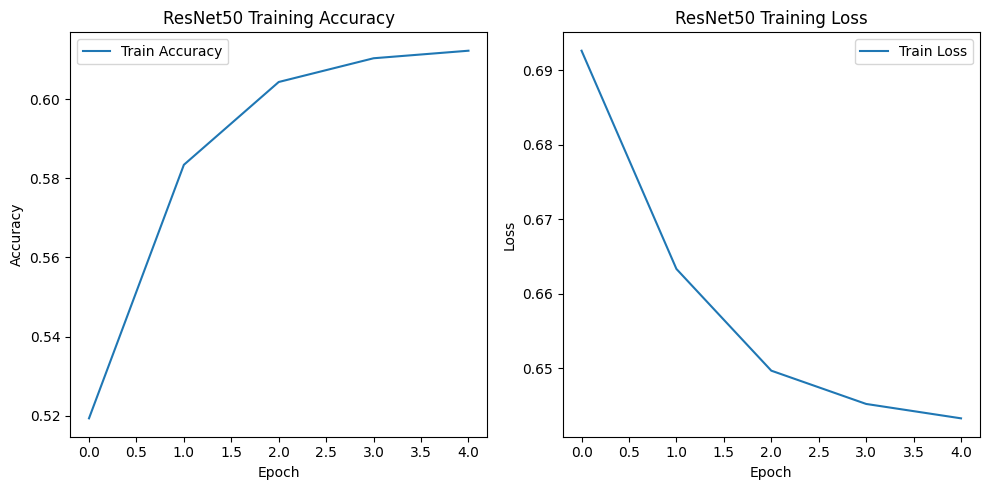

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(history_resnet.history["accuracy"], label="Train Accuracy")
plt.title("ResNet50 Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(history_resnet.history["loss"], label="Train Loss")
plt.title("ResNet50 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

VGG19 MODEL

In [27]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Base model (VGG19)
base_model = tf.keras.applications.VGG19(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze base layers
base_model.trainable = False

# Model
vgg_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # preprocessing layer
    layers.Lambda(tf.keras.applications.vgg19.preprocess_input),

    base_model,
    layers.Flatten(),   # VGG me flatten bhi use hota hai

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

# Compile
vgg_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

vgg_model.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,447,425 (100.89 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [28]:
#Train VGG19
history_vgg = vgg_model.fit(
    train_ds,
    epochs=5
)
#Evaluate VGG19
test_loss_vgg, test_acc_vgg = vgg_model.evaluate(test_ds)
print("VGG19 Accuracy:", test_acc_vgg)

Epoch 1/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 279s 134ms/step - accuracy: 0.4991 - loss: 0.7176
Epoch 2/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 268s 134ms/step - accuracy: 0.4976 - loss: 0.6932
Epoch 3/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 268s 133ms/step - accuracy: 0.4981 - loss: 0.6932
Epoch 4/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 268s 133ms/step - accuracy: 0.4968 - loss: 0.6932
Epoch 5/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 268s 133ms/step - accuracy: 0.4976 - loss: 0.6932
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 130ms/step - accuracy: 0.5000 - loss: 0.6932
VGG19 Accuracy: 0.5


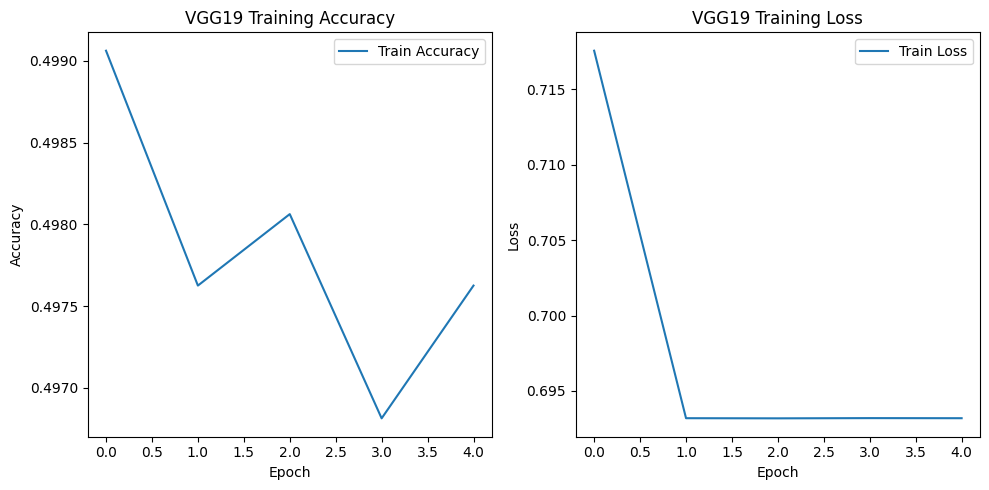

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(history_vgg.history["accuracy"], label="Train Accuracy")
plt.title("VGG19 Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(history_vgg.history["loss"], label="Train Loss")
plt.title("VGG19 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

EfficientNetB0

In [32]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Base model
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze base layers
base_model.trainable = False

# Model
efficientnet_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # EfficientNet preprocessing
    layers.Lambda(tf.keras.applications.efficientnet.preprocess_input),

    base_model,
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

# Compile
efficientnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [33]:
#Train EfficientNet
history_eff = efficientnet_model.fit(
    train_ds,
    epochs=5
)
#Evaluate EfficientNet
test_loss_eff, test_acc_eff = efficientnet_model.evaluate(test_ds)
print("EfficientNet Accuracy:", test_acc_eff)

Epoch 1/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 74s 23ms/step - accuracy: 0.4975 - loss: 0.6946
Epoch 2/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 48s 24ms/step - accuracy: 0.4949 - loss: 0.6933
Epoch 3/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 49s 24ms/step - accuracy: 0.4968 - loss: 0.6932
Epoch 4/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 48s 24ms/step - accuracy: 0.4964 - loss: 0.6932
Epoch 5/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 48s 24ms/step - accuracy: 0.4984 - loss: 0.6932
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.5000 - loss: 0.6932
EfficientNet Accuracy: 0.5


COMPARE MODEL ACCURACY

In [34]:
print("\n📊 Model Comparison:")
print(f"CNN Accuracy: {test_acc:.4f}")
print(f"MobileNet Accuracy: {test_acc_m:.4f}")
print(f"ResNet50 Accuracy: {test_acc_r:.4f}")
print(f"VGG19 Accuracy: {test_acc_vgg:.4f}")
print(f"EfficientNet Accuracy: {test_acc_eff:.4f}")


📊 Model Comparison:
CNN Accuracy: 0.9105
MobileNet Accuracy: 0.5000
ResNet50 Accuracy: 0.7311
VGG19 Accuracy: 0.5000
EfficientNet Accuracy: 0.5000


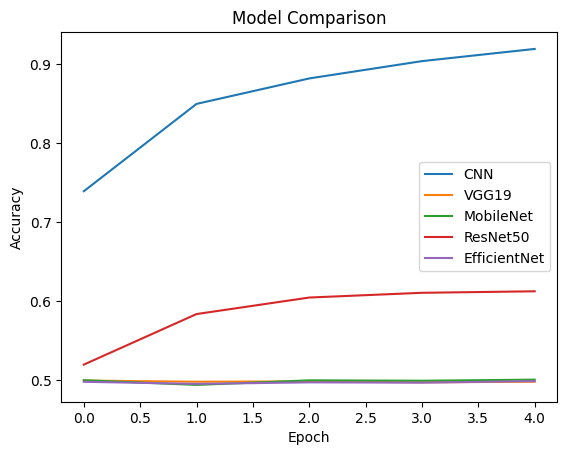

In [35]:
#GRAPH COMPARISON
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='CNN')
plt.plot(history_vgg.history['accuracy'], label='VGG19')
plt.plot(history_mobilenet.history['accuracy'], label='MobileNet')
plt.plot(history_resnet.history['accuracy'], label='ResNet50')
plt.plot(history_eff.history['accuracy'], label='EfficientNet')

plt.title("Model Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

CONFUSION MATRIX  & CLASSIFICATION REPORT FOR BEST MODEL

---



In [41]:
#prediction
import numpy as np


y_pred_prob = cnn_model.predict(test_ds)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
#truelabels
true_labels = []

for _, labels in test_ds:
    true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)

500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step


In [42]:
print("Best Model: CNN")
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, y_pred)
print("Confusion Matrix:\n", cm)

Best Model: CNN
Confusion Matrix:
 [[3670  330]
 [ 386 3614]]


In [43]:
labels = ["Real", "Fake"]

print("\nConfusion Matrix with Labels:\n")
print(f"          Predicted")
print(f"            {labels[0]}      {labels[1]}")
print(f"Actual {labels[0]}   {cm[0][0]}      {cm[0][1]}")
print(f"Actual {labels[1]}   {cm[1][0]}      {cm[1][1]}")


Confusion Matrix with Labels:

          Predicted
            Real      Fake
Actual Real   3670      330
Actual Fake   386      3614


In [44]:
from sklearn.metrics import classification_report

print("\nClassification Report:\n")
print(classification_report(true_labels, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      4000
           1       0.92      0.90      0.91      4000

    accuracy                           0.91      8000
   macro avg       0.91      0.91      0.91      8000
weighted avg       0.91      0.91      0.91      8000

